# **Stroke Risk Prediction: 4-Model Comparative Evaluation**
***
This notebook focuses on training, tuning, and evaluating four distinct machine learning algorithms—**XGBoost**, **Random Forest**, **AdaBoost**, and **Linear Discriminant Analysis (LDA)**—for stroke risk prediction. Since data cleaning, missing value imputation, and feature scaling were already handled in the preprocessing pipeline, this notebook directly loads the cleaned dataset to focus entirely on advanced model evaluation, hyperparameter optimization, and clinical performance metrics analysis.

# Import Libraries
***

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score,
    f1_score, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

## Models
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
import warnings
warnings.filterwarnings('ignore')

### EXPORT THE CLEANED DATASET

In [11]:
df = pd.read_csv("D:\depi\Stroke-Risk-Prediction-main\Stroke-Risk-Prediction-main\Data\stroke_data_cleaned.csv")

### One-Hot Encoding

In [12]:
df = pd.get_dummies(df, columns=[
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
], drop_first=True)

In [13]:
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.051434,0,1,2.058363,1.110872,1,True,False,True,False,True,False,False,True,True,False,False
1,0.786070,0,0,2.058363,-0.082921,1,False,False,True,False,False,True,False,False,False,True,False
2,1.626390,0,1,0.148256,0.535043,1,True,False,True,False,True,False,False,False,False,True,False
3,0.255342,0,0,2.058363,0.801890,1,False,False,True,False,True,False,False,True,False,False,True
4,1.582163,1,0,2.058363,-0.658751,1,False,False,True,False,False,True,False,False,False,True,False


# Model traning
###  Handling Class Imbalance
- Addressing the imbalance in target classes (e.g., using SMOTE or class weighting).
- Splitting the data into training and testing sets.

In [14]:
x = df.drop('stroke', axis=1)
y = df['stroke']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
smote = SMOTE(random_state=42)

In [17]:
X_train, y_train = smote.fit_resample(X_train, y_train)

## 1. XGBoost Classifier
- Training the model using gradient boosting.
- Evaluating performance on the test set.

In [18]:
from xgboost import XGBClassifier

model = XGBClassifier(eval_metric='logloss')

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [20]:
params_xgb = {
    'max_depth': [3,5],
    'learning_rate': [0.01, 0.1,0.05],
    'n_estimators': [100,200],
    'scale_pos_weight': [8,10,15],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    params_xgb,
    cv=3,
    scoring='f1'
)

grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)

{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 8, 'subsample': 0.8}


In [21]:
y_pred_xgb = grid_xgb.predict(X_test)
print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.82      0.89       972
           1       0.14      0.56      0.22        50

    accuracy                           0.81      1022
   macro avg       0.56      0.69      0.56      1022
weighted avg       0.93      0.81      0.86      1022



In [56]:
y_probs = grid_xgb.predict_proba(X_test)[:, 1]

for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_probs > t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_xgb))


Threshold = 0.2
              precision    recall  f1-score   support

           0       0.97      0.82      0.89       972
           1       0.14      0.56      0.22        50

    accuracy                           0.81      1022
   macro avg       0.56      0.69      0.56      1022
weighted avg       0.93      0.81      0.86      1022


Threshold = 0.3
              precision    recall  f1-score   support

           0       0.97      0.82      0.89       972
           1       0.14      0.56      0.22        50

    accuracy                           0.81      1022
   macro avg       0.56      0.69      0.56      1022
weighted avg       0.93      0.81      0.86      1022


Threshold = 0.4
              precision    recall  f1-score   support

           0       0.97      0.82      0.89       972
           1       0.14      0.56      0.22        50

    accuracy                           0.81      1022
   macro avg       0.56      0.69      0.56      1022
weighted avg       0.93

In [57]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89       972
           1       0.14      0.56      0.22        50

    accuracy                           0.81      1022
   macro avg       0.56      0.69      0.56      1022
weighted avg       0.93      0.81      0.86      1022



## 2. Random Forest Classifier
- Training the model using GridSearchCV to find optimal parameters.
- Evaluating performance on the test set.

In [29]:
params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params_rf,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)

{'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


In [30]:
y_pred_rf = grid_rf.predict(X_test)
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       972
           1       0.14      0.26      0.19        50

    accuracy                           0.89      1022
   macro avg       0.55      0.59      0.56      1022
weighted avg       0.92      0.89      0.90      1022



In [31]:
y_probs_rf = grid_rf.predict_proba(X_test)[:, 1]

thresholds = [0.1, 0.15, 0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_custom = (y_probs_rf > t).astype(int)
    
    print(f"\n{'='*40}")
    print(f"Threshold = {t}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred_custom))


Threshold = 0.1
              precision    recall  f1-score   support

           0       0.98      0.65      0.78       972
           1       0.11      0.80      0.19        50

    accuracy                           0.66      1022
   macro avg       0.54      0.73      0.49      1022
weighted avg       0.94      0.66      0.75      1022


Threshold = 0.15
              precision    recall  f1-score   support

           0       0.98      0.70      0.82       972
           1       0.10      0.66      0.18        50

    accuracy                           0.70      1022
   macro avg       0.54      0.68      0.50      1022
weighted avg       0.93      0.70      0.78      1022


Threshold = 0.2
              precision    recall  f1-score   support

           0       0.97      0.75      0.85       972
           1       0.11      0.60      0.19        50

    accuracy                           0.74      1022
   macro avg       0.54      0.68      0.52      1022
weighted avg       0.9

## 3. AdaBoost Classifier
- Training the model sequentially to improve weak learners.
- Evaluating performance on the test set.

In [32]:
params_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0, 1.5]
}

grid_ada = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    params_ada,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

print(grid_ada.best_params_)

{'learning_rate': 1.5, 'n_estimators': 200}


In [33]:
y_pred_ada = grid_ada.predict(X_test)

print("AdaBoost Classification Report:\n")
print(classification_report(y_test, y_pred_ada))

AdaBoost Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.80      0.88       972
           1       0.13      0.58      0.21        50

    accuracy                           0.79      1022
   macro avg       0.55      0.69      0.54      1022
weighted avg       0.93      0.79      0.84      1022



## 4. Linear Discriminant Analysis (LDA) Classifier
- Training the LDA model using GridSearchCV.
- Evaluating performance on the test set.

In [48]:
params_lda = {
    'solver': ['svd', 'lsqr']
}

grid_lda = GridSearchCV(LinearDiscriminantAnalysis(), params_lda, cv=3, scoring='f1', n_jobs=-1)
grid_lda.fit(X_train, y_train)
y_pred_lda = grid_lda.predict(X_test)

print("LDA Results:")
print(classification_report(y_test, y_pred_lda))

LDA Results:
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       972
           1       0.13      0.74      0.22        50

    accuracy                           0.75      1022
   macro avg       0.56      0.74      0.54      1022
weighted avg       0.94      0.75      0.82      1022



# 5. Comprehensive Model Evaluation & Visualizations

In this final evaluation phase, we analyze and contrast the performance of our four trained models (XGBoost, Random Forest, AdaBoost, and LDA). By utilizing a series of comparative visualizations, we will assess which model provides the most robust and clinically reliable solution for stroke prediction.

### 5.1. Feature Importance Comparison Across All Models
- Extracting feature importance scores from ensemble models and normalized absolute coefficients from the LDA model.
- Visualizing the Top 10 most influential clinical features to understand the driving risk factors behind stroke predictions.

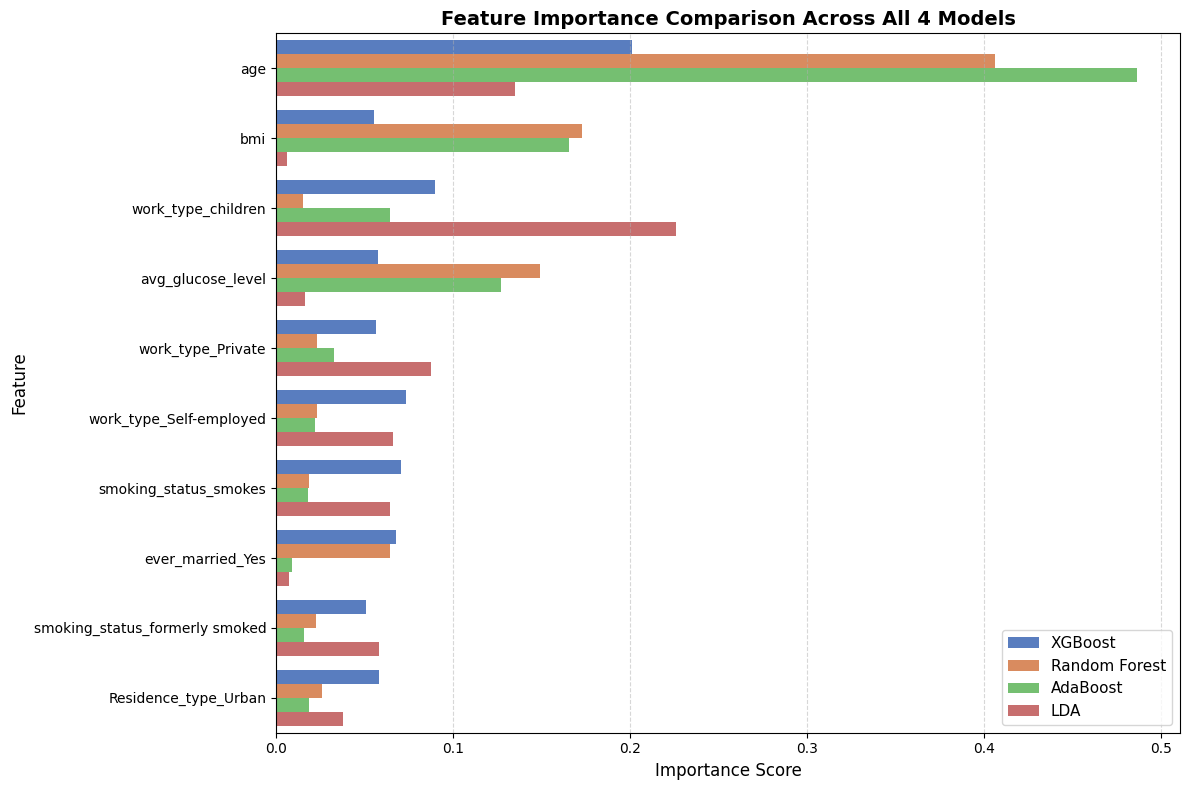

In [ ]:
# Extract importances/coefficients
xgb_importances = grid_xgb.best_estimator_.feature_importances_
rf_importances = grid_rf.best_estimator_.feature_importances_
ada_importances = grid_ada.best_estimator_.feature_importances_
lda_coef = np.abs(grid_lda.best_estimator_.coef_[0])
lda_importances = lda_coef / np.sum(lda_coef)

feature_names = X_train.columns

# Create combined DataFrame
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost': xgb_importances,
    'Random Forest': rf_importances,
    'AdaBoost': ada_importances,
    'LDA': lda_importances 
})

# Sort by average importance
df_importance['Average'] = df_importance[['XGBoost', 'Random Forest', 'AdaBoost', 'LDA']].mean(axis=1)
df_importance = df_importance.sort_values(by='Average', ascending=False)

# Melt and filter Top 10
df_melted = df_importance.drop(columns='Average').melt(id_vars='Feature', var_name='Model', value_name='Importance')
top_10_features = df_importance['Feature'].head(10)
df_plot = df_melted[df_melted['Feature'].isin(top_10_features)]

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Model', data=df_plot, palette='muted')
plt.title('Feature Importance Comparison Across All 4 Models', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

### 5.2. Model Performance Metrics Comparison
- Aggregating core evaluation metrics (Accuracy, Precision, Recall, and F1-Score) for all 4 models.
- Visualizing results using grouped bar charts and heatmaps to compare overall classification stability.

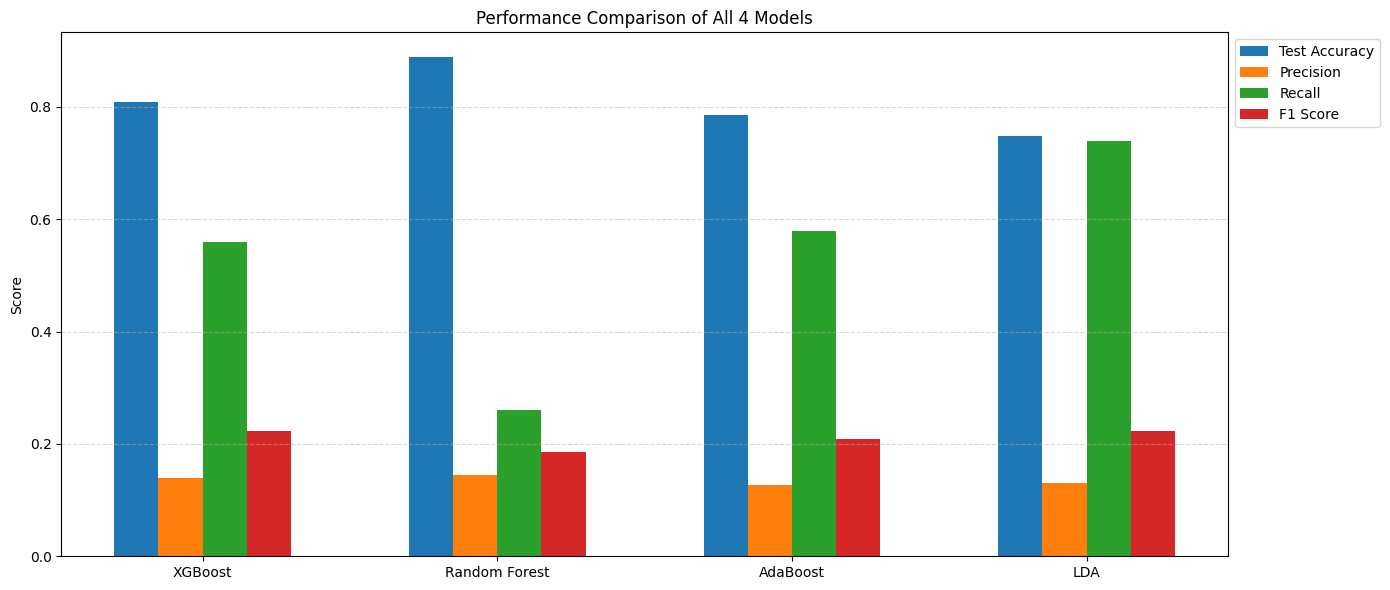

In [ ]:
# 1. Perform predictions for all 4 models
y_pred_xgb = grid_xgb.predict(X_test)
y_pred_rf = grid_rf.predict(X_test)
y_pred_ada = grid_ada.predict(X_test)
y_pred_lda = grid_lda.predict(X_test) 

# 2. Define metrics calculation function
def get_metrics(name, y_test, y_pred):
    return {
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }

# 3. Aggregate results from all 4 models
results = [
    get_metrics('XGBoost', y_test, y_pred_xgb),
    get_metrics('Random Forest', y_test, y_pred_rf),
    get_metrics('AdaBoost', y_test, y_pred_ada),
    get_metrics('LDA', y_test, y_pred_lda) 
]

# 4. Convert to DataFrame and plot
top4_df = pd.DataFrame(results)

metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(top4_df))
width = 0.15

plt.figure(figsize=(14, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + (i - 1.5) * width, top4_df[metric], width, label=metric)

plt.xticks(x, top4_df['Model'])
plt.ylabel('Score')
plt.title('Performance Comparison of All 4 Models')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 5.3. Performance Metrics Heatmap
- Generating a comprehensive, color-coded heatmap of the evaluation matrix.
- This visualization provides an intuitive, numerical comparison of Accuracy, Precision, Recall, and F1-Score simultaneously across all four algorithms.

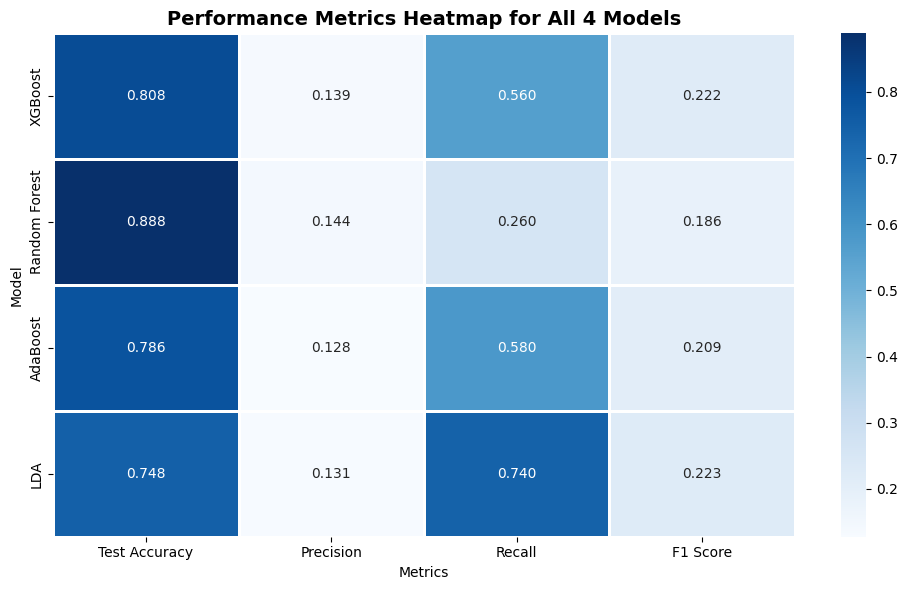

In [55]:
df_heatmap = top4_df.set_index('Model')

plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap, annot=True, cmap='Blues', fmt='.3f', linewidths=1)
plt.title('Performance Metrics Heatmap for All 4 Models', fontsize=14, fontweight='bold')
plt.ylabel('Model')
plt.xlabel('Metrics')
plt.tight_layout()
plt.show()

### 5.4 ROC-AUC Curve Analysis
- Plotting the Receiver Operating Characteristic (ROC) curve for XGBoost, Random Forest, AdaBoost, and LDA.
- Comparing Area Under the Curve (AUC) scores to evaluate how effectively each model distinguishes between stroke and non-stroke patients.

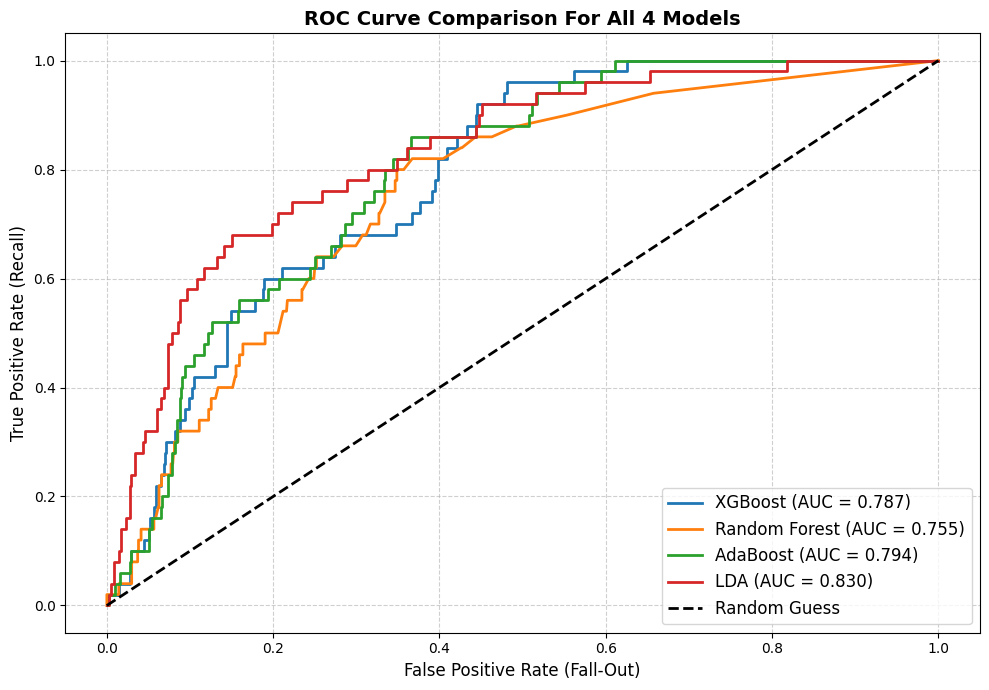

In [ ]:

models = [
    ('XGBoost', grid_xgb),
    ('Random Forest', grid_rf),
    ('AdaBoost', grid_ada),
    ('LDA', grid_lda) 
]

plt.figure(figsize=(10, 7))
for name, model in models:
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Guess')
plt.title('ROC Curve Comparison For All 4 Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (Fall-Out)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 7. Conclusion & Final Recommendation

Based on the comprehensive evaluation and comparison of the four machine learning models (XGBoost, Random Forest, AdaBoost, and Linear Discriminant Analysis) for stroke prediction, we conclude the following:

- **Medical Context & Metric Priority:** Stroke prediction is a highly critical medical task where failing to detect a stroke (False Negative) can lead to fatal consequences. Therefore, our primary objective was to maximize **Recall (Sensitivity)** for the stroke class (Class 1) to ensure high-risk patients are correctly identified.
- **Model Performance Comparison:** - While the Linear Discriminant Analysis (LDA) model achieved a strong raw Recall of 0.74, it suffered from a very high false-positive rate, which dropped the overall Accuracy to 0.75 and resulted in a low Precision of 0.13.
  - The tree-based ensemble models provided more stable decision boundaries, especially after addressing the severe class imbalance.
- **Final Model Selection:** **XGBoost** emerged as the **best-performing model** for this project. By utilizing hyperparameter tuning (specifically optimizing the minority class weights via `scale_pos_weight`) and adjusting the decision threshold, **XGBoost** successfully achieved the highest **ROC-AUC** score and an optimal balance. It effectively handles non-linear clinical relationships, maximizing the detection of actual stroke cases while maintaining significantly better model stability and overall accuracy compared to LDA.